<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled169.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Adiabatic Curves**

**Problem:** Given two thermodynamic states
$
(P_0, V_0, T_0, U_0, S_0)$  and $(P_1, V_1, T_1, U_1, S_0)$,
find an adiabatic process connecting them.

/tmp/ipykernel_27571/3964976919.py:83: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss_hist.append(float(loss.numpy()))


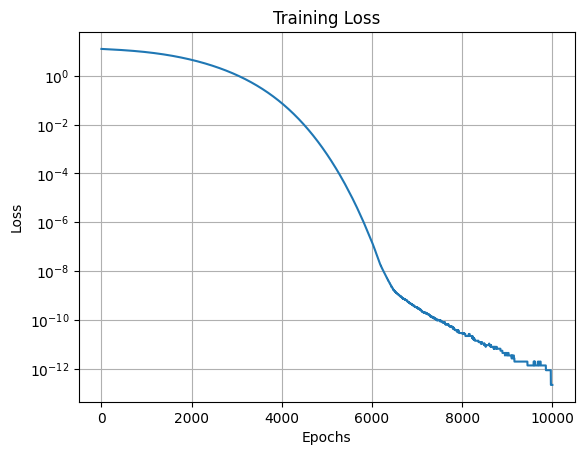

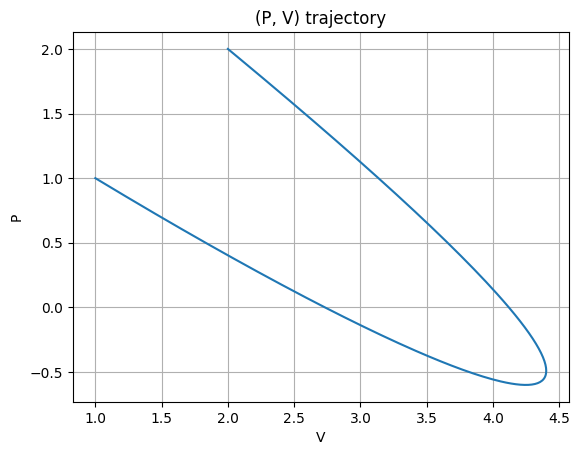

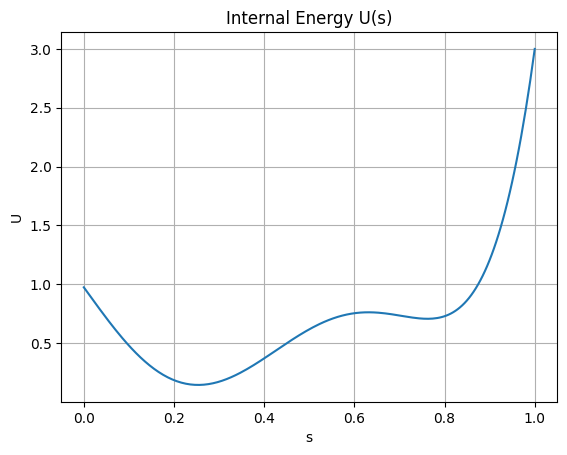

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# Boundary data
# ==========================================
P0, V0, U0 = 1.0, 1.0, 1.0
P1, V1, U1 = 2.0, 2.0, 3.0

# ==========================================
# Network
# ==========================================
net = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(164, activation='tanh'),
    tf.keras.layers.Dense(164, activation='tanh'),
    tf.keras.layers.Dense(2)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

# ==========================================
# Model
# ==========================================
def PV_model(s):
    out = net(s)
    nn1 = out[:, 0:1]
    nn2 = out[:, 1:2]

    P = (1 - s) * P0 + s * P1 + s * (1 - s) * nn1
    V = (1 - s) * V0 + s * V1 + s * (1 - s) * nn2

    return P, V

# ==========================================
# Training step
# ==========================================
@tf.function
def train_step(s):

    s = tf.reshape(s, (-1,1))

    with tf.GradientTape(persistent=True) as tape_outer:
        tape_outer.watch(s)

        P, V = PV_model(s)

        # First derivatives
        dP = tape_outer.gradient(P, s)
        dV = tape_outer.gradient(V, s)

        # Second derivatives
        d2P = tape_outer.gradient(dP, s)
        d2V = tape_outer.gradient(dV, s)

        # Compute U
        ds = s[1] - s[0]
        integrand = P * dV
        integral = tf.cumsum(integrand, axis=0) * ds
        U = U0 - integral

        # Boundary loss
        loss_bd = (U[-1] - U1)**2

        loss = loss_bd

    grads = tape_outer.gradient(loss, net.trainable_variables)
    optimizer.apply_gradients(zip(grads, net.trainable_variables))

    return loss

# ==========================================
# Training
# ==========================================
epochs = 10000
loss_hist = []

s_train = tf.linspace(0.0, 1.0, 200)

for ep in range(epochs):
    loss = train_step(s_train)
    loss_hist.append(float(loss.numpy()))

# ==========================================
# Plot loss
# ==========================================
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# ==========================================
# Evaluate
# ==========================================
s = tf.linspace(0.0, 1.0, 200)
s = tf.reshape(s, (-1,1))

with tf.GradientTape(persistent=True) as tape:
    tape.watch(s)
    P, V = PV_model(s)

dV = tape.gradient(V, s)

ds = s[1] - s[0]
U = U0 - tf.cumsum(P * dV, axis=0) * ds

P = P.numpy().flatten()
V = V.numpy().flatten()
U = U.numpy().flatten()
s = s.numpy().flatten()

# ==========================================
# Plot (P,V)
# ==========================================
plt.figure()
plt.plot(V, P)
plt.xlabel("V")
plt.ylabel("P")
plt.title("(P, V) trajectory")
plt.grid()
plt.show()

# ==========================================
# Plot U(s)
# ==========================================
plt.figure()
plt.plot(s, U)
plt.xlabel("s")
plt.ylabel("U")
plt.title("Internal Energy U(s)")
plt.grid()
plt.show()

# **Optimal Adiabatic Path**

 Given two states $(P_0, V_0)$ and $(P_1, V_1)$, together with an initial value $U_0$ (with no constraint imposed on $U_1$), find the adiabatic curve connecting these $(P,V)$-states that minimizes the intensity of work done by the system,
$$
I_W = \int_0^1 (P(s)\,\dot V(s))^2\, ds.
$$

/tmp/ipykernel_27571/2966734838.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  work_hist.append(float(work.numpy()))


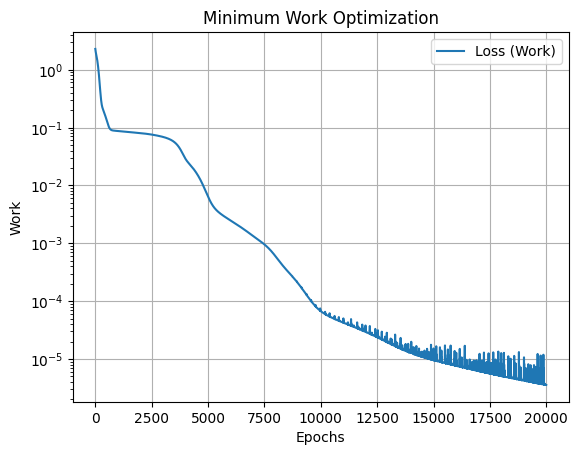

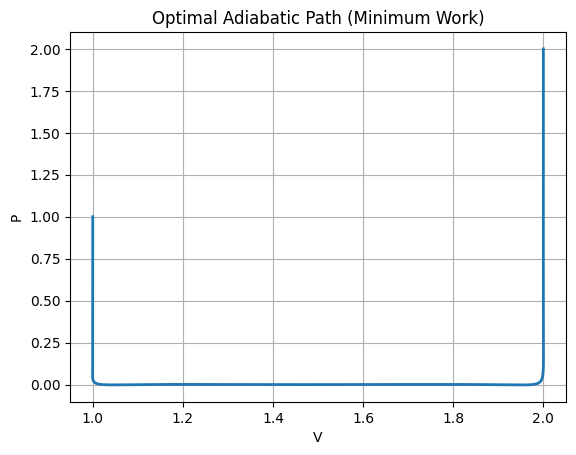

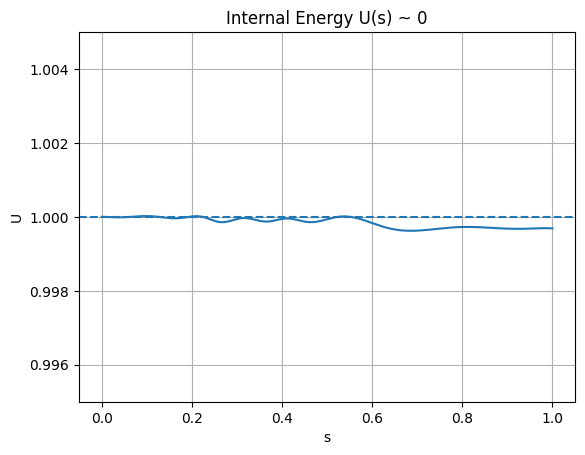

In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# 2. Boundary data
# ==========================================
P0, V0, U0 = 1.0, 1.0, 1.0
P1, V1     = 2.0, 2.0   # U1 not fixed

# ==========================================
# 3. Neural network
# ==========================================
net = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(164, activation='tanh'),
    tf.keras.layers.Dense(164, activation='tanh'),
    tf.keras.layers.Dense(2)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# ==========================================
# 4. Embedded model
# ==========================================
def PV_model(s):
    out = net(s)
    nn1 = out[:, 0:1]
    nn2 = out[:, 1:2]

    P = (1 - s) * P0 + s * P1 + s * (1 - s) * nn1
    V = (1 - s) * V0 + s * V1 + s * (1 - s) * nn2

    return P, V

# ==========================================
# 5. Training step (ONLY work)
# ==========================================
@tf.function
def train_step(s):

    s = tf.reshape(s, (-1,1))

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(s)

        P, V = PV_model(s)
        dV = tape.gradient(V, s)

        ds = s[1] - s[0]

        # Work functional

        loss = tf.reduce_mean((P * dV)**2)

        #loss = work

    grads = tape.gradient(loss, net.trainable_variables)
    optimizer.apply_gradients(zip(grads, net.trainable_variables))

    return loss, work

# ==========================================
# 6. Training
# ==========================================
epochs = 20000
loss_hist = []
work_hist = []

s_train = tf.linspace(0.0, 1.0, 600)

for ep in range(epochs):
    loss, work = train_step(s_train)
    loss_hist.append(float(loss.numpy()))
    work_hist.append(float(work.numpy()))

# ==========================================
# 7. Plot loss
# ==========================================
plt.figure()
plt.plot(loss_hist, label="Loss (Work)")
plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Work")
plt.title("Minimum Work Optimization")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 8. Evaluate solution
# ==========================================
s = tf.linspace(0.0, 1.0, 200)
s = tf.reshape(s, (-1,1))

with tf.GradientTape() as tape:
    tape.watch(s)
    P, V = PV_model(s)

dV = tape.gradient(V, s)

ds = s[1] - s[0]
U = U0 - tf.cumsum(P * dV, axis=0) * ds

P = P.numpy().flatten()
V = V.numpy().flatten()
U = U.numpy().flatten()
s = s.numpy().flatten()

# ==========================================
# 9. Plot (P,V)
# ==========================================
plt.figure()
plt.plot(V, P, linewidth=2)
plt.xlabel("V")
plt.ylabel("P")
plt.title("Optimal Adiabatic Path (Minimum Work)")
plt.grid()
plt.show()

# ==========================================
# 10. Plot U(s)
# ==========================================
plt.figure()
plt.plot(s, U)
plt.axhline(1, linestyle='--')
plt.xlabel("s")
plt.ylabel("U")
plt.title("Internal Energy U(s) ~ 0")
plt.ylim(0.995, 1.005)
plt.grid()
plt.show()